In [184]:
# 라이브러리 불러오기
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [185]:
# 파일 불러오기
mpg_df = pd.read_excel('C:/juehyeon/aice_test/materials/datasets/auto_mpg.xlsx')

In [186]:
# 데이터 미리보기
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1,ford torino


In [187]:
mpg_df.info() # 결측치가 origin,name빼고 다 존재함. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           481 non-null    float64
 1   cylinders     496 non-null    float64
 2   displacement  492 non-null    float64
 3   horsepower    491 non-null    float64
 4   weight        490 non-null    float64
 5   acceleration  492 non-null    float64
 6   model_year    496 non-null    float64
 7   origin        498 non-null    int64  
 8   name          498 non-null    object 
dtypes: float64(7), int64(1), object(1)
memory usage: 35.1+ KB


In [188]:
# 컬럼명 변경하기 
mpg_df = mpg_df.rename(columns = {
    'mpg': '연비',
    'cylinders' : '실린더 수',
    'displacement' : '배기량',
    'horsepower' : '마력',
    'weight' : '차량 무게',
    'acceleration' : '가속 성능',
    'model_year' : '차량 출시 연도',
    'origin' : '제조 국가 코드',
    'name' : '차량 이름'
})

In [189]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   연비        481 non-null    float64
 1   실린더 수     496 non-null    float64
 2   배기량       492 non-null    float64
 3   마력        491 non-null    float64
 4   차량 무게     490 non-null    float64
 5   가속 성능     492 non-null    float64
 6   차량 출시 연도  496 non-null    float64
 7   제조 국가 코드  498 non-null    int64  
 8   차량 이름     498 non-null    object 
dtypes: float64(7), int64(1), object(1)
memory usage: 35.1+ KB


In [190]:
# 결측치 처리하기
## 결측치가 존재하는 행 삭제
del_df = mpg_df.dropna(axis = 0)
del_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 455 entries, 0 to 497
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   연비        455 non-null    float64
 1   실린더 수     455 non-null    float64
 2   배기량       455 non-null    float64
 3   마력        455 non-null    float64
 4   차량 무게     455 non-null    float64
 5   가속 성능     455 non-null    float64
 6   차량 출시 연도  455 non-null    float64
 7   제조 국가 코드  455 non-null    int64  
 8   차량 이름     455 non-null    object 
dtypes: float64(7), int64(1), object(1)
memory usage: 35.5+ KB


In [191]:
print(mpg_df.shape, '->', del_df.shape) # 삭제 행 확인

(498, 9) -> (455, 9)


In [192]:
del_df.isna().sum() # 결측치 삭제 확인

연비          0
실린더 수       0
배기량         0
마력          0
차량 무게       0
가속 성능       0
차량 출시 연도    0
제조 국가 코드    0
차량 이름       0
dtype: int64

<Axes: xlabel='마력', ylabel='연비'>

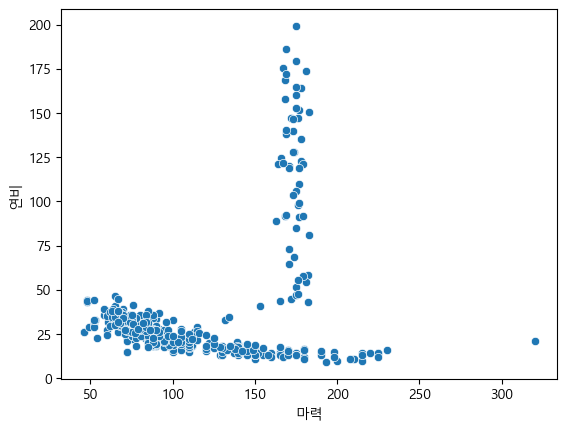

In [193]:
# 이상치 제거
## 한글 적용
plt.rc('font', family = 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

## 이상치 확인하기
sns.scatterplot(
    data = del_df, 
    x = '마력', 
    y = '연비'
)

In [194]:
## 이상치 삭제 -> 마력이 150 이상이며 연비가 50이상인 것 삭제 
del_df = del_df[(del_df.마력 < 150) | (del_df.연비 <50)]

In [195]:
## 이상치 삭제 확인
((del_df.마력 >= 150) & (del_df.연비 >= 50)).sum()

np.int64(0)

In [196]:
# 상관관계 파악하기
col_list = ['배기량', '마력', '차량 무게', '가속 성능']
corr_matrix = del_df[col_list].corr()
corr_matrix

,배기량,마력,차량 무게,가속 성능
배기량,1.000000,0.859654,0.935449,-0.487637
마력,0.859654,1.000000,0.826202,-0.592745
차량 무게,0.935449,0.826202,1.000000,-0.362986
가속 성능,-0.487637,-0.592745,-0.362986,1.000000


<Axes: >

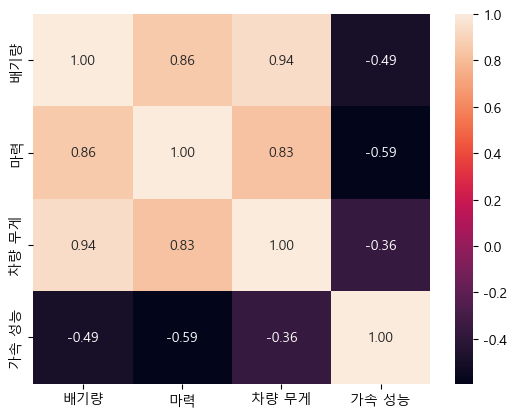

In [197]:
## 히트맵으로 표현하기 
sns.heatmap(data = del_df[col_list].corr(), annot = True, fmt = '.2f')

## 해석
1. 배기량과 차량 무게는 상관계수가 0.94로 4개 변수 중 가장 높아 다중공선성이 우려됨 
2. 마력과 배기량은 상관계수가 0.86으로 낮은 편은 아님
3. 배기량과 차량 무게는 높은 상관관계를 가지므로, 예측력이나 변수 중요도를 고려하여 차량 무게를 제거한다. 
- **다중공선성** : 독립변수들 간에 강한 상관관계가 나타나는 현상
  -> 해결방법 : 상관관계가 높은 독립변수중 하나 혹은 일부를 제거
  

In [198]:
# 불필요한 변수 제거 
## 다중공선성 우려되는 변수 제거 -> 차량 무게 
del_df = del_df.drop(columns = '차량 무게')


In [199]:
## 차량 출시연도, 제조 국가 코드, 차량 이름 제거 
del_cols = ['차량 출시 연도', '제조 국가 코드', '차량 이름']
del_df = del_df.drop(columns = del_cols)

In [200]:
## 제거 확인
del_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 403 entries, 0 to 471
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   연비      403 non-null    float64
 1   실린더 수   403 non-null    float64
 2   배기량     403 non-null    float64
 3   마력      403 non-null    float64
 4   가속 성능   403 non-null    float64
dtypes: float64(5)
memory usage: 18.9 KB


In [201]:
## 변수에 할당 
clear_df = del_df.copy()

In [202]:
# 범주형 변수 인코딩
encoding_df = pd.get_dummies(data = clear_df, columns = ['실린더 수'],  drop_first = True)

In [203]:
## 인코딩 확인
encoding_df.head()

,연비,배기량,마력,가속 성능,실린더 수_4.0,실린더 수_5.0,실린더 수_6.0,실린더 수_8.0
0,18.0,307.0,130.0,12.0,False,False,False,True
1,15.0,350.0,165.0,11.5,False,False,False,True
2,18.0,318.0,150.0,11.0,False,False,False,True
3,16.0,304.0,150.0,12.0,False,False,False,True
4,17.0,302.0,140.0,10.5,False,False,False,True


In [204]:
# 데이터 분리
X = encoding_df.drop(columns = '연비')
y = encoding_df['연비']

In [205]:
## 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [206]:
## 훈련용, 검증용 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape) # 데이터 분리 확인

(322, 7) (81, 7) (322,) (81,)


In [207]:
# 스케일링 하기
## 라이브러리 임포트
from sklearn.preprocessing import StandardScaler

In [208]:
## 모델 객체 생성
scaler = StandardScaler()

In [209]:
## 데이터 스케일링
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

In [210]:
# 머신러닝 - SVM 회귀 모델 사용
## 라이브러리 임포트
from sklearn.svm import SVR

In [211]:
## 모델 객체 생성
svr = SVR(kernel = 'rbf', C = 1.0, epsilon = 0.2)

In [212]:
## 모델 훈련
svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.2
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [213]:
# 머신러닝 - 랜덤포레스트 회귀 모델 사용
## 라이브러리 임포트
from sklearn.ensemble import RandomForestRegressor

In [214]:
## 모델 객체 생성
rfr = RandomForestRegressor(n_estimators = 200, max_depth = 10, min_samples_split = 7, random_state = 42)

In [215]:
## 모델 학습
rfr.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,7
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [216]:
# 딥러닝 설계
## 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.models import Sequential
tf.random.set_seed(42)

In [223]:
## 모델 생성
dl_model = Sequential([
    Input(shape = (X_train.shape[1], )),
    Dense(64, activation = 'tanh'),
    Dropout(0.3),
    Dense(32, activation = 'tanh'),
    Dropout(0.3),
    Dense(16, activation = 'tanh'),
    Dense(8, activation = 'tanh'),
    Dense(1, activation = 'linear')
])  

In [224]:
## 모델 컴파일
dl_model.compile(
    optimizer = 'rmsprop',
    loss = 'mean_absolute_error', 
    metrics = ['mean_squared_error']
)

In [225]:
history = dl_model.fit(
    X_train, y_train,
    epochs = 50, 
    batch_size = 8
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 23.0486 - mean_squared_error: 595.1168
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.5999 - mean_squared_error: 530.1112
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.5587 - mean_squared_error: 488.7835
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.9551 - mean_squared_error: 465.2249
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.5112 - mean_squared_error: 447.5292
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.1310 - mean_squared_error: 432.9867
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.7639 - mean_squared_error: 419.2453
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.4002 - mean_squared_error: 405.8926
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.0376 - mean_squared_error: 392.8548
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17.6752 - mean_squared_error: 380.0933
Epoch 11/50
41/41 ━━━━━━━━━━━

In [226]:
dl_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,532 (25.52 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,267 (12.77 KB)

In [227]:
# 딥러닝 예측 

In [230]:
## 시뮬레이션 데이터 생성
simul_data = np.array([[200.0, 95.0, 15.0, 1, 0, 0, 0]])

In [233]:
## 시뮬레이션 데이터 스케일링
simul_data = scaler.transform(simul_data)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [234]:
deep_pre = dl_model.predict(simul_data)
deep_pre

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


array([[19.682608]], dtype=float32)